# **PreProcessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import itertools
import plotly.offline as py
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import warnings
import os

from sklearn.model_selection import  train_test_split
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_curve , roc_auc_score , precision_recall_curve , average_precision_score , confusion_matrix , classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

In [ ]:
df = pd.read_csv("/content/insurance_claims.csv")
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

In [ ]:
features = [
    'incident_severity',
    'insured_hobbies',
    'incident_type',
    'collision_type',
    'incident_state',
    'authorities_contacted',
    'property_claim',
    'vehicle_claim',
    'policy_annual_premium',
    'insured_zip',
    'policy_number',
    'total_claim_amount',
    'months_as_customer',
    'injury_claim',
    'age',
    'insured_occupation',
    'capital-gains',
    "fraud_reported"
]


In [ ]:
df = df[features]

**Handling missing value on numeric features**

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

def imputer_Num(data, imputer=None):

    # data.drop(columns = "_c39" , inplace = True)

    num_cols = [col for col in data.columns if data[col].dtype in ['int64', 'int32', 'float64']]

    if imputer is None:
        imputer = SimpleImputer(missing_values=np.nan, strategy="median")
        imputer.fit(data[num_cols])

    data_imputed = pd.DataFrame(
        imputer.transform(data[num_cols]),
        index=data.index,
        columns=num_cols
    )

    return data_imputed


In [ ]:
df_numeric = imputer_Num(df)

**Handling missing value on categorical feature**

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

def imputer_Cat(data, imputer=None):

    data = data.replace('?', np.nan)


    cat_cols = [col for col in data.columns if data[col].dtype == "object"]

    if imputer is None:
        imputer = SimpleImputer(missing_values=np.nan, strategy="constant" , fill_value="UNKNOWN")

        imputer.fit(data[cat_cols])

    data_imputed = pd.DataFrame(
        imputer.transform(data[cat_cols]),
        index=data.index,
        columns=cat_cols
    )

    return data_imputed


In [ ]:
df_categorical = imputer_Cat(df)

In [ ]:
# Concatenating Both numeric and categorical feature after applying imputer
df = pd.concat(
    [df_numeric, df_categorical],
    axis=1
)


**Scaling Data**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def scaling_data(data, scaler=None):


    num_cols = data.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()


    if len(num_cols) == 0:
        raise ValueError("No numeric columns found for scaling")

    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(data[num_cols])

    data_scaled = pd.DataFrame(
        scaler.transform(data[num_cols]),
        index=data[num_cols].index,
        columns=num_cols
    )

    return data_scaled, scaler


In [ ]:
df_scaled, scaler = scaling_data(df)

df = pd.concat(
    [df.drop(columns=df_scaled.columns), df_scaled],
    axis=1
)


**Encoding Teachnique**

In [ ]:
cat_cols = [col for col in df.columns if df[col].dtype == "object"]


In [ ]:
nominal = ['authorities_contacted', 'incident_state', 'insured_hobbies']
ordinal = ['collision_type', 'incident_type', 'incident_severity']

**One Hot Encoder (OHE)**

In [ ]:
from sklearn.preprocessing import  OneHotEncoder , LabelEncoder , OrdinalEncoder

def OHE_cat(data , encoder_col = None , encoder = None) ->pd.DataFrame:

  data_ohe = data[nominal]

  if encoder == None:
    encoder = OneHotEncoder(
        handle_unknown="ignore" ,
        drop = "if_binary"
    )

    encoder.fit(data_ohe)
    encoder_col = encoder.get_feature_names_out(data_ohe.columns)


  data_encoded = encoder.transform(data_ohe).toarray()
  data_encoded = pd.DataFrame(data_encoded ,
                              index = data_ohe.index ,
                              columns = encoder_col
                              )


  return data_encoded , encoder_col , encoder

In [ ]:
df_OHE , encoder_col , encoder_type = OHE_cat(df)

**Oridinal Encoding**

In [ ]:
def OE_cat(data, encoder = None) -> pd.DataFrame:

    data_le = data[ordinal]

    collision_type = ['UNKNOWN', 'Side Collision', 'Rear Collision', 'Front Collision']
    incident_severity = ['Trivial Damage','Minor Damage','Major Damage','Total Loss']
    incident_type = ['Parked Car','Single Vehicle Collision','Multi-vehicle Collision','Vehicle Theft']

    if encoder == None:
        # Create object
        encoder = OrdinalEncoder(categories=[collision_type, incident_type,incident_severity])
        encoder.fit(data_le)

    ## Transform the data
    data_encoded = encoder.transform(data_le)
    data_encoded = pd.DataFrame(data_encoded,
                                index = data_le.index,
                                columns = data_le.columns)

    # save the object

    return data_encoded, encoder

In [ ]:
df_oe , encoder_type = OE_cat(df)

In [ ]:
# Concatenating categorical feature after applying OneHotEncoding , Oridinal Encoding
df = df.drop(columns=ordinal)
df = pd.concat([df, df_oe], axis=1)
df.shape

(1000, 18)

In [ ]:
df = df.drop(columns=nominal)
df = pd.concat([df, df_OHE], axis=1)
df.shape

(1000, 47)

**Label Encoding**

In [ ]:
from sklearn.preprocessing import  LabelEncoder

def label_encoding(data):

    le = LabelEncoder()

    data_encoded = le.fit_transform(data)

    return data_encoded



In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:

  df[col] = label_encoding(df[col])


# **Train Test Split**

**Train-Test Split: Train and Test plays an important role when it comes to train any ML Model.How you splitting your whole data it's really an important factor.when it comes to splitting the data we usually use 80-20 , 70-30 , 75-25 sort of splitting technique where**

- 80-20 says that

    - 80% would be your train data and 20% would be your test
- 70-20 says that

    - 70% would be your train data and 30% would be your test
- 90-10 says that

    - 90% would be your train data dandn 10% would be your test

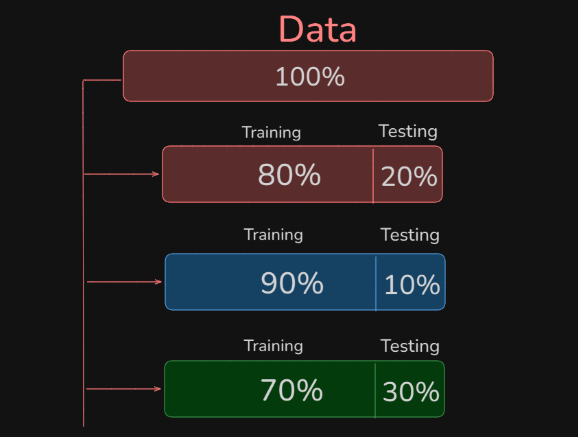

In [ ]:
target_col = ["fraud_reported"]
# Splitting the data
cols  = [i for i in df.columns if i not in target_col]
target_col = target_col

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(df[cols] , df[target_col] , test_size = 0.2 , random_state = 42)

In [ ]:

def model(model , x_train , x_test  , y_train , y_test , title):
  model.fit(x_train , y_train)
  predictions = model.predict(x_test)
  probabilities = model.predict_proba(x_test)

  print(classification_report(y_test , predictions))
  print("Accuracy Score - " , accuracy_score(y_test , predictions))
  print("Precision Score - " , precision_score(y_test , predictions))
  print("Recall Score - " , recall_score(y_test , predictions))

  confu_matrix = confusion_matrix(y_test , predictions)
  # print("Confusion matrix - " , confu_matrix)

  # sns.heatmap(confu_matrix  , annot=True , cmap=plt.cm.copper)
  # plt.title(f"Confusion matrix" , fontsize = 12)
  sns.heatmap(confu_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=["Not fraud", "fraud"],
                    yticklabels=["Not fraud", "fraud"])
  plt.xlabel("Predicted")
  plt.ylabel("Actual")

  model_roc_auc = roc_auc_score(y_test , predictions)
  print("Roc Auc Score - " , model_roc_auc)

  fpr , tpr , threshold = roc_curve(y_test , predictions)
  dt_roc_curve(fpr , tpr , title)

**Logistic Regression**

In [ ]:
# Baseline model
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(
    C = 100,
    # fit_intercept=True ,
    # max_iter=300 ,
    # multi_class="ovr",
    # penalty="l2" ,
    # random_state=None ,
    # solver="liblinear" ,
)

log.fit(x_train , y_train)
predictions = log.predict(x_test)
probabilities = log.predict_proba(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



In [ ]:
print( "Classification report - " , classification_report(y_test , predictions))
print("Accuracy Score - " , accuracy_score(y_test , predictions))
print("Precision Score - " , precision_score(y_test , predictions))
print("Recall Score - " , recall_score(y_test , predictions))

Classification report -                precision    recall  f1-score   support

           0       0.78      0.97      0.86       145
           1       0.75      0.27      0.40        55

    accuracy                           0.78       200
   macro avg       0.76      0.62      0.63       200
weighted avg       0.77      0.78      0.73       200

Accuracy Score -  0.775
Precision Score -  0.75
Recall Score -  0.2727272727272727


**Let’s understand certain metrics terms:**

- True Positives: Correctly Classified Fraud

- False Positives: Incorrectly Classified Fraud

- True Negative: Correctly Classified Non-Fraud

- False Negative: Incorrectly Classified Non-Fraud

- Precision: Precision measures the proportion of correctly predicted positive instances out of all instances predicted as positive. It answers the question: “Out of all the items the model identified as relevant, how many were actually relevant?

    - True Positives / (True Positives + False Positives)
- Recall : Recall measures the proportion of correctly predicted positive instances out of all actual positive instances. It answers the question: “Out of all the actual relevant items, how many did the model correctly identify

    - True Positives / (True Positives + False Negatives)

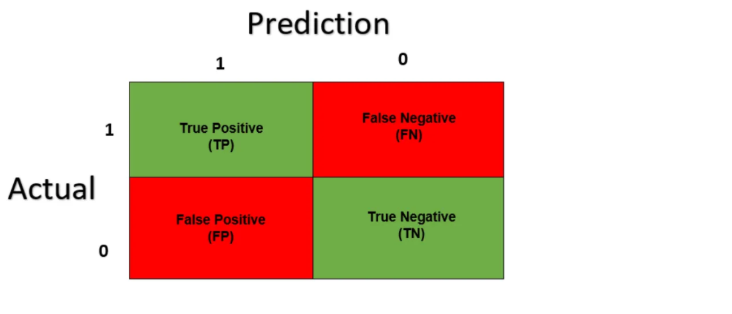


**Confusion Matrix:**

Understanding Model Predictions: TN, FP, FN, and TP Explained When evaluating the performance of a classification model — such as one detecting churn — it’s crucial to understand the different types of predictions the model can make. Here’s a simple breakdown:

1. True Negatives (TN)
    - Model Predicts: Non-fraudulent (N)

    - Actual Reality: Non-fraudulent (N)

    - Description: The model correctly identifies a legitimate claim.

    - Business Impact: This is the most common scenario. The insurance company can process the claim smoothly, ensuring high customer satisfaction and no wasted investigation costs.

2. False Positives (FP) — Type I Error
    - Model Predicts: Fraudulent (Y)

    - Actual Reality: Non-fraudulent (N)

    - Description: The model "cries wolf." It wrongly flags an honest customer's claim as fraud.

    - Business Impact: This leads to a bad customer experience. An innocent person’s claim is delayed, they are investigated, and the company spends money on investigators for no reason.

3. False Negatives (FN) — Type II Error
    - Model Predicts: Non-fraudulent (N)

    - Actual Reality: Fraudulent (Y)

    - Description: A "missed catch." The model fails to detect a fraudster and labels the claim as legitimate.

    - Business Impact: This is the most dangerous error for an insurance company. The company pays out a large sum (like the total_claim_amount) to a criminal. It results in direct financial loss.

4. True Positives (TP)
    - Model Predicts: Fraudulent (Y)

    - Actual Reality: Fraudulent (Y)

    - Description: The model successfully catches the fraudster.

    - Business Impact: This is a huge win! As we calculated earlier, catching these frauds can save the company millions of dollars (e.g., the $14.6 million saved in this dataset).

In [ ]:
# confusion matrix
conf_matrix = confusion_matrix(y_test , predictions)
print(conf_matrix)

# roc_auc_score
model_roc_auc = roc_auc_score(y_test  , predictions)
print("Area under curve - " , model_roc_auc)

[[140   5]
 [ 40  15]]
Area under curve -  0.6191222570532915


Text(0.5, 1.0, 'Confusion matrix - Logistic Rgression')

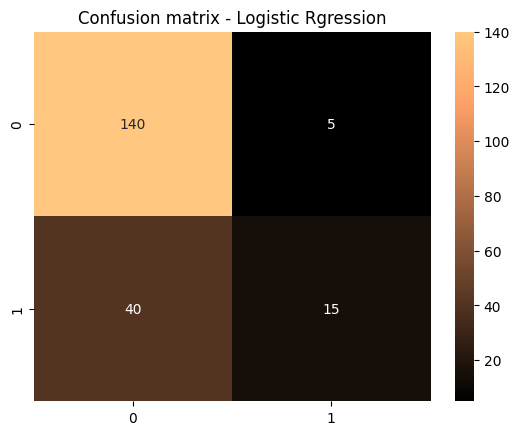

In [ ]:
y_pred = log.predict(x_test)

log_reg_cf = confusion_matrix(y_test , y_pred)

# Logistic refression confusion matrix
sns.heatmap(log_reg_cf  , annot=True , cmap=plt.cm.copper ,    fmt='d')
plt.title("Confusion matrix - Logistic Rgression" , fontsize = 12)

**Let’s see the ROC CURVE**

- True Positive Rate (TPR) : TPR is the ratio of correctly identified positive
    - TPR = TP / (TP + FN), where TP is - - True Positives and False Negatives.
- False Positive Ratio (FPR) : FPR is the ratio of incorrectly identified negative instances (false positives) to the total number of actual negative instances.
    - FPR = FP / (FP + TN), where FP is False Positives and TN is True Negatives.

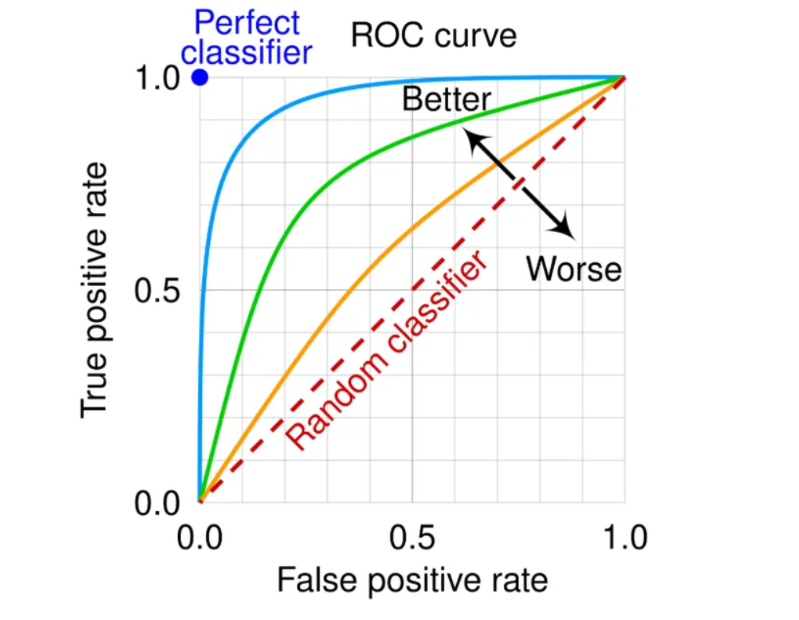

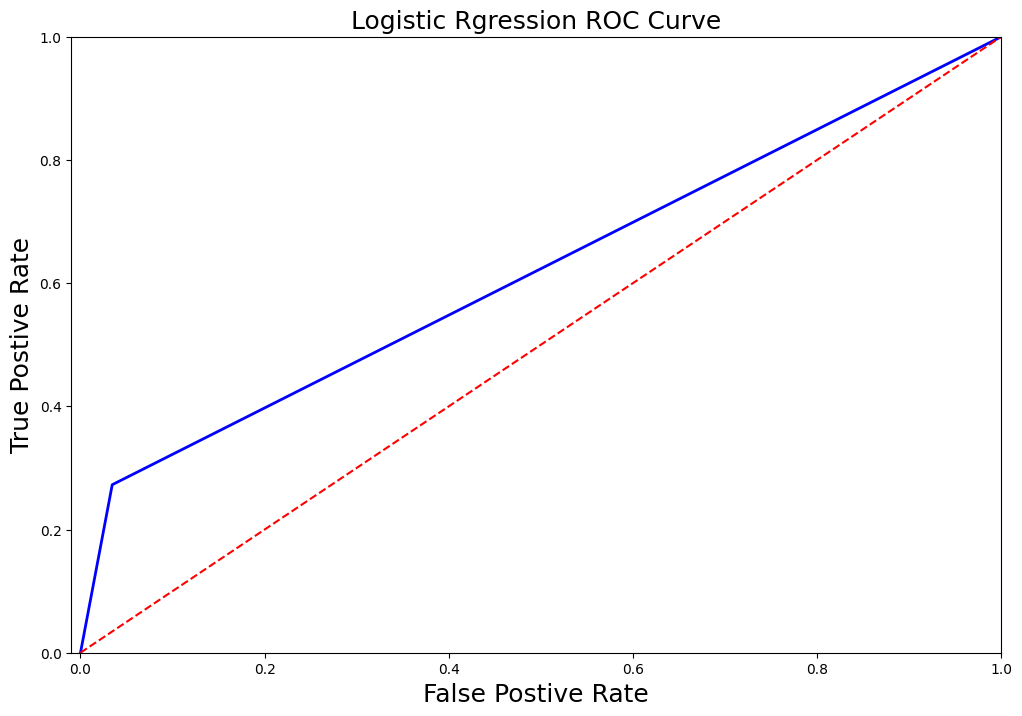

In [ ]:
fpr , tpr , threshold = roc_curve(y_test , predictions)

def logistic_roc_curve(log_fpr , log_tpr):
  plt.figure(figsize = (12 , 8))
  plt.title("Logistic Rgression ROC Curve" , fontsize = 18)
  plt.plot(log_fpr , log_tpr , "b-" , linewidth = 2)
  plt.plot([0,1] , [0,1] , "r--")
  plt.xlabel("False Postive Rate" , fontsize = 18)
  plt.ylabel("True Postive Rate" , fontsize = 18)
  plt.axis([-0.01 , 1 , 0 , 1])
  plt.show()

logistic_roc_curve(fpr , tpr)

 **DecisionTree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# from graphviz import tree
# from graphviz import Source
# from IPython.display import SVG , display

In [ ]:
dt = DecisionTreeClassifier(
    max_depth = 8 ,
    splitter = "best"  ,
    criterion="gini" ,
)
dt.fit(x_train  , y_train)

DecisionTreeClassifier(max_depth=8)

In [ ]:
predictions = dt.predict(x_test)
probability = dt.predict_proba(x_test)

In [ ]:
print(classification_report(y_test , predictions))
print("accuracy score - " , accuracy_score(y_test , predictions))
print("Precision - " , precision_score(y_test , predictions))
print("Recall - " , recall_score(y_test , predictions))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       145
           1       0.63      0.62      0.62        55

    accuracy                           0.80       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.79      0.80      0.79       200

accuracy score -  0.795
Precision -  0.6296296296296297
Recall -  0.6181818181818182


In [ ]:

conf_matrix = confusion_matrix(y_test , predictions)
print("Confusion matrix - " , conf_matrix)

dt_model_auc = roc_auc_score(y_test , predictions)
print("Roc AUC Curve - " , dt_model_auc)

Confusion matrix -  [[125  20]
 [ 21  34]]
Roc AUC Curve -  0.7401253918495297


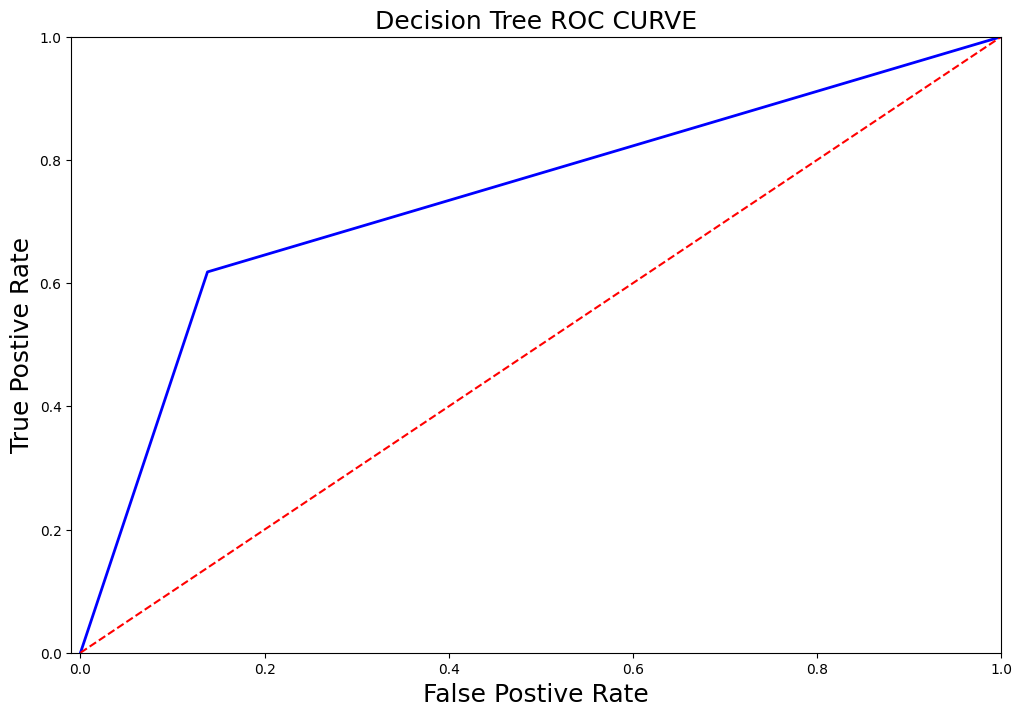

In [ ]:
fpr , tpr , threshold = roc_curve(y_test , predictions)

def dt_roc_curve(log_fpr , log_tpr , title):
  plt.figure(figsize = (12 , 8))
  plt.title(title , fontsize = 18)
  plt.plot(log_fpr , log_tpr , "b-" , linewidth = 2)
  plt.plot([0,1] , [0,1] , "r--")
  plt.xlabel("False Postive Rate" , fontsize = 18)
  plt.ylabel("True Postive Rate" , fontsize = 18)
  plt.axis([-0.01 , 1 , 0 , 1])
  plt.show()

dt_roc_curve(fpr , tpr , "Decision Tree ROC CURVE")

Decision Tree slightly working better as compare to Logistic Regression  Area under curve - 0.7366

**SMOTE Technique -- For Handling Imbalanced data**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_smote, y_smote = smote.fit_resample(x_train, y_train)
x_smote = pd.DataFrame(data = x_smote, columns=cols)
y_smote = pd.DataFrame(data = y_smote, columns=target_col)

log.fit(x_smote , y_smote)
predictions = log.predict(x_test)
probabilities = log.predict_proba(x_test)

print(classification_report(y_test , predictions))
print("Accuracy Score - " , accuracy_score(y_test , predictions))
print("Precision Score - " , precision_score(y_test , predictions))
print("Recall Score - " , recall_score(y_test , predictions))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



              precision    recall  f1-score   support

           0       0.77      0.70      0.73       145
           1       0.35      0.44      0.39        55

    accuracy                           0.62       200
   macro avg       0.56      0.57      0.56       200
weighted avg       0.65      0.62      0.64       200

Accuracy Score -  0.625
Precision Score -  0.35294117647058826
Recall Score -  0.43636363636363634


Area under curve -  0.5664576802507838


Text(0.5, 1.0, 'Confusion matrix - Logistic Rgression')

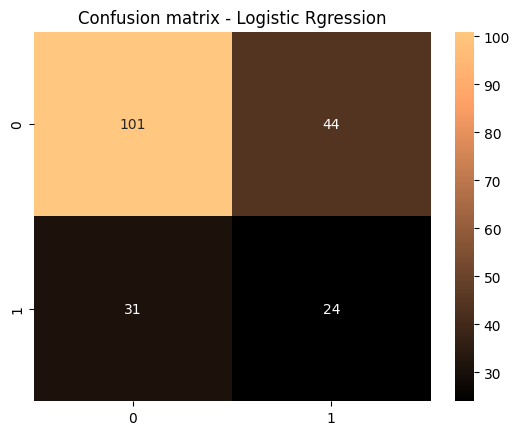

In [ ]:
model_roc_auc = roc_auc_score(y_test  , predictions)
print("Area under curve - " , model_roc_auc)

y_pred = log.predict(x_test)

log_reg_cf = confusion_matrix(y_test , y_pred)

# Logistic refression confusion matrix
sns.heatmap(log_reg_cf  , annot=True , cmap=plt.cm.copper , fmt='d')
plt.title("Confusion matrix - Logistic Rgression" , fontsize = 12)

**RandomForest**

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



              precision    recall  f1-score   support

           0       0.75      0.97      0.85       145
           1       0.67      0.15      0.24        55

    accuracy                           0.74       200
   macro avg       0.71      0.56      0.54       200
weighted avg       0.73      0.74      0.68       200

Accuracy Score -  0.745
Precision Score -  0.6666666666666666
Recall Score -  0.14545454545454545
Roc Auc Score -  0.5589341692789969


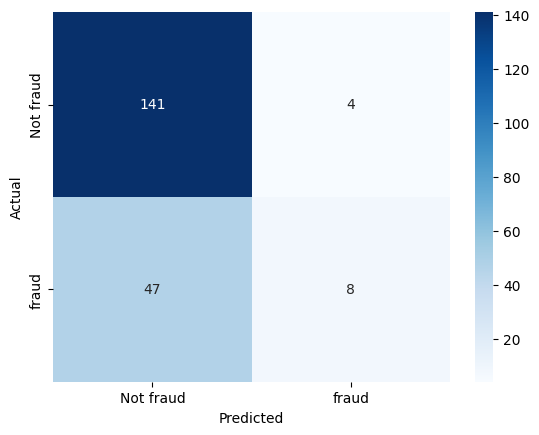

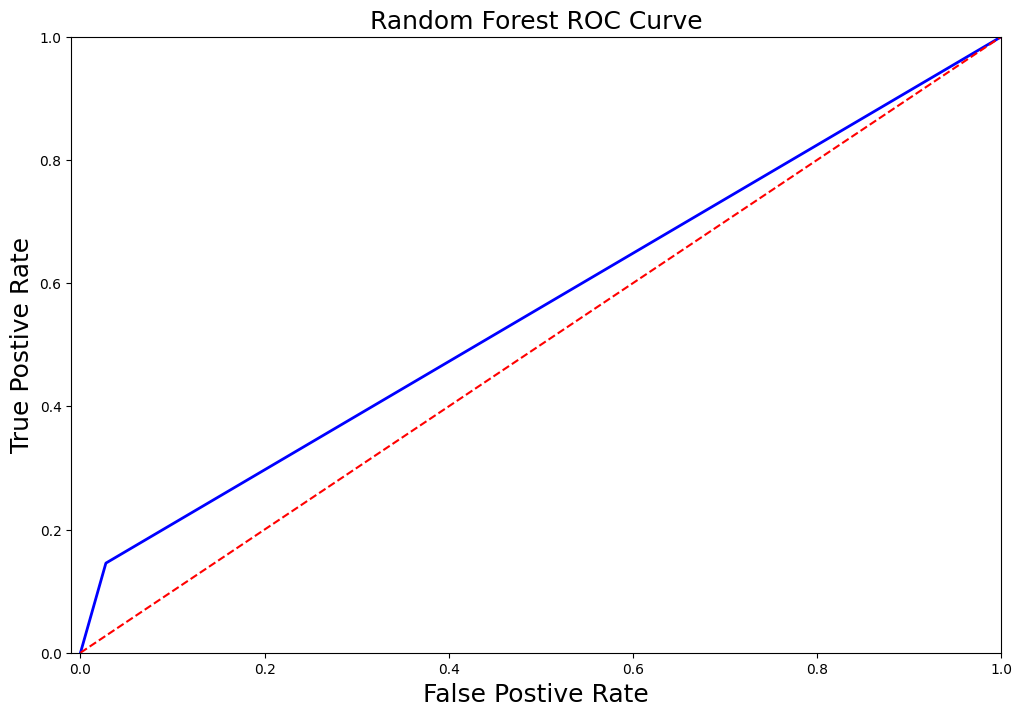

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators = 600 ,
    max_depth = 9 ,
    criterion = "gini"
)

model(rfc , x_train , x_test , y_train , y_test , "Random Forest ROC Curve")

**LightGBM**

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 192, number of negative: 608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000311 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2299
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240000 -> initscore=-1.152680
[LightGBM] [Info] Start training from score -1.152680
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

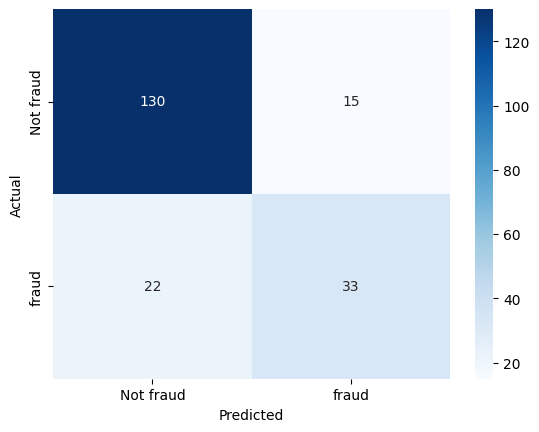

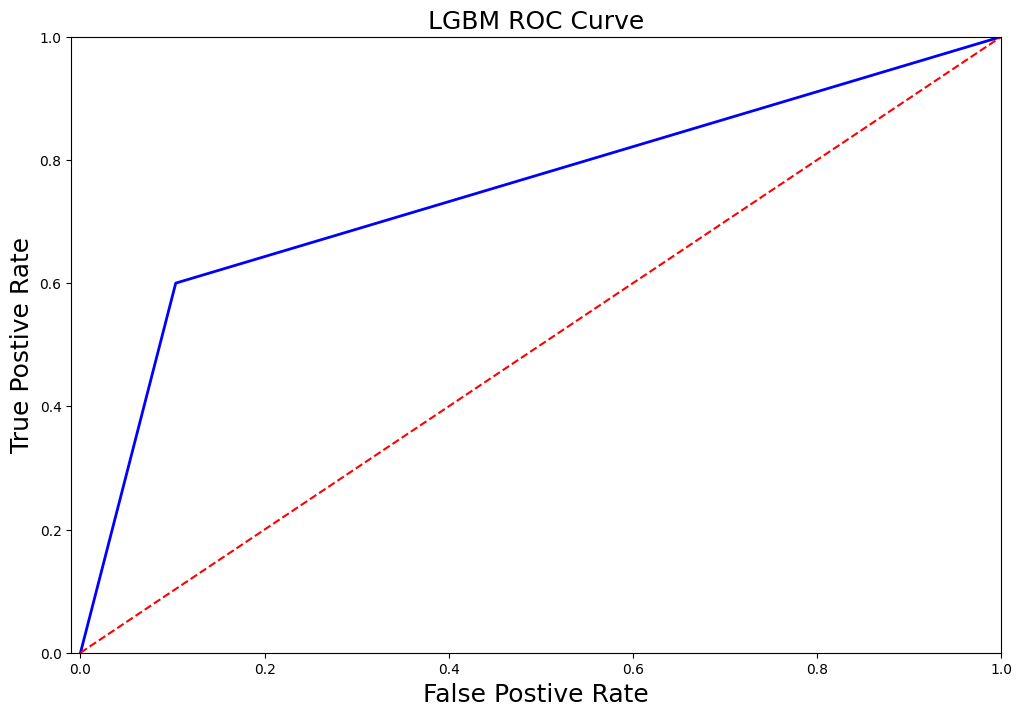

In [ ]:
from lightgbm import LGBMClassifier

lgbmc = LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                        learning_rate=0.5, max_depth=7, min_child_samples=20,
                        min_child_weight=0.001, min_split_gain=0.0, n_estimators=100,
                        n_jobs=-1, num_leaves=500, objective='binary', random_state=None,
                        reg_alpha=0.0, reg_lambda=0.0, silent=True, subsample=1.0,
                        subsample_for_bin=200000, subsample_freq=0)

model(lgbmc , x_train,x_test , y_train , y_test , "LGBM ROC Curve")

**LGBMClassifier ROC AUC =  0.7482758620689656 Much better then RandomForest Model**

**XGBoost**

              precision    recall  f1-score   support

           0       0.83      0.88      0.86       145
           1       0.63      0.53      0.57        55

    accuracy                           0.79       200
   macro avg       0.73      0.71      0.72       200
weighted avg       0.78      0.79      0.78       200

Accuracy Score -  0.785
Precision Score -  0.6304347826086957
Recall Score -  0.5272727272727272
Roc Auc Score -  0.7050156739811912


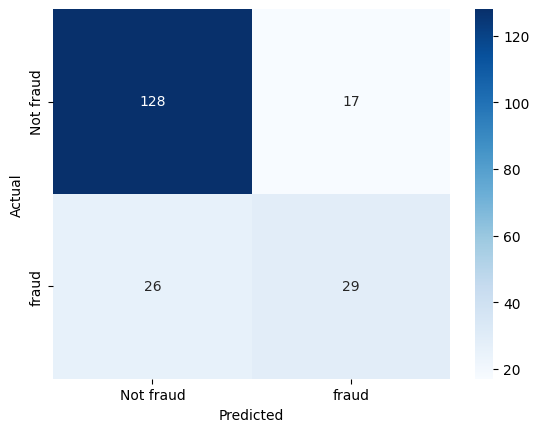

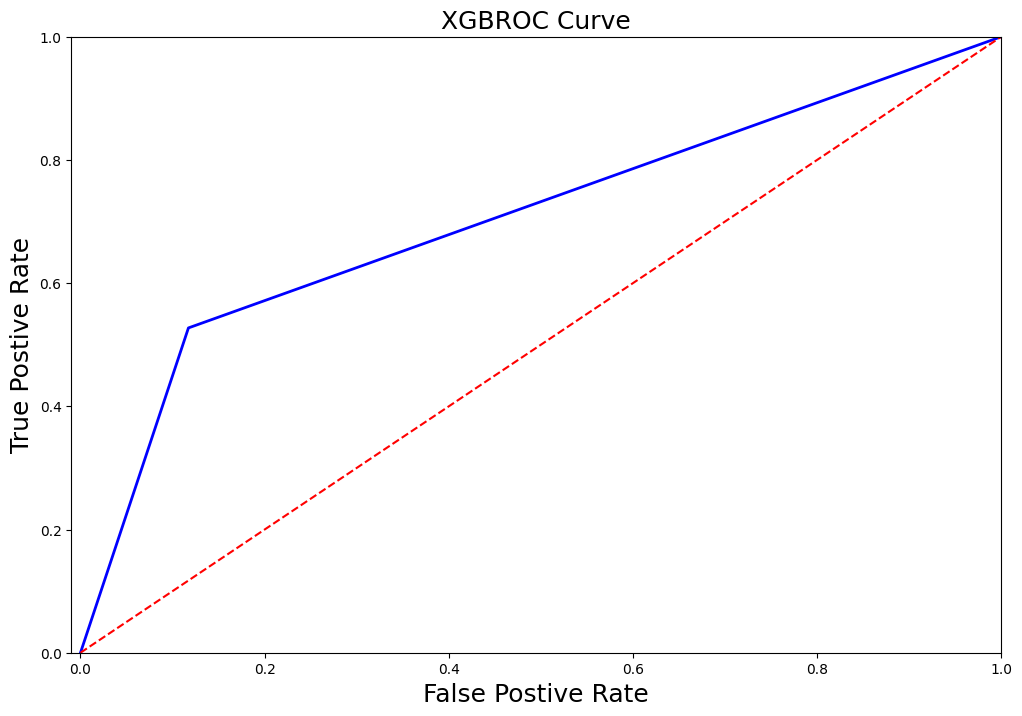

In [ ]:
from math import gamma
from xgboost import XGBClassifier

xgc = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
                    colsample_bytree=1, gamma=0, learning_rate=0.9, max_delta_step=0,
                    max_depth=7, min_child_weight=1, n_estimators=100,
                    n_jobs=1, objective='binary:logistic', random_state=0,
                    reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
                     subsample=1)
model(xgc , x_train , x_test , y_train , y_test , "XGBROC Curve")

**GradientBoosting**

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



              precision    recall  f1-score   support

           0       0.84      0.90      0.87       145
           1       0.67      0.55      0.60        55

    accuracy                           0.80       200
   macro avg       0.75      0.72      0.73       200
weighted avg       0.79      0.80      0.79       200

Accuracy Score -  0.8
Precision Score -  0.6666666666666666
Recall Score -  0.5454545454545454
Roc Auc Score -  0.7210031347962382


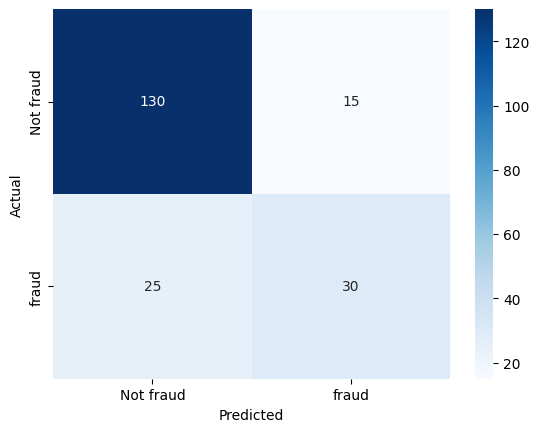

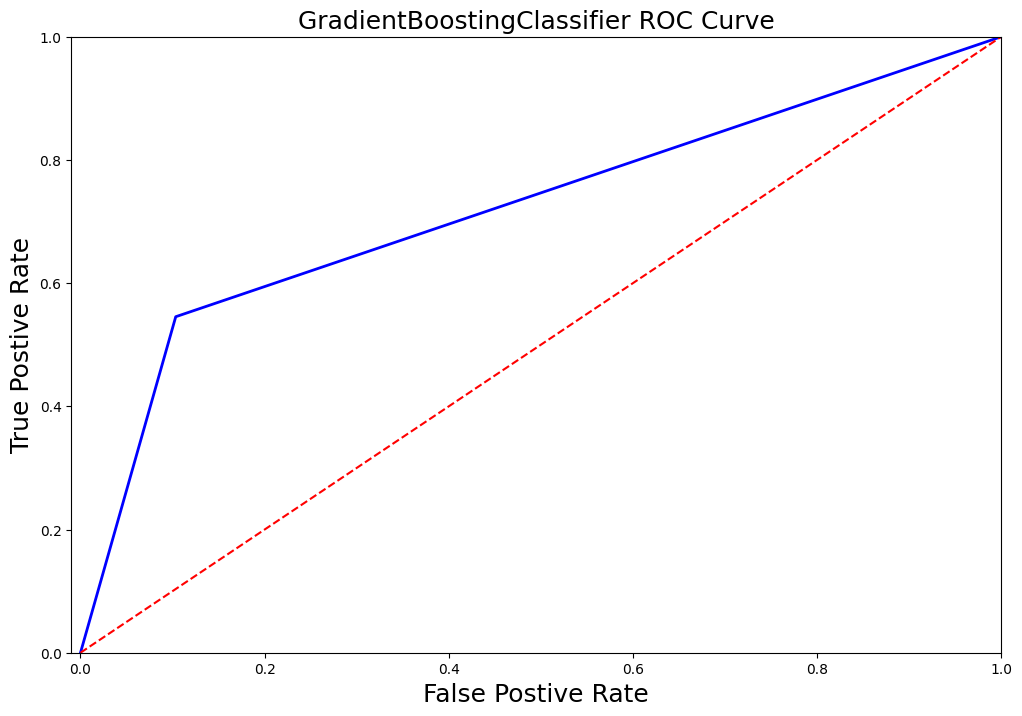

In [ ]:

from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(
    n_estimators=100 ,
    random_state=124
)
model(gbc , x_train ,x_test , y_train , y_test , "GradientBoostingClassifier ROC Curve")

**Model Perfomance**

In [ ]:
models = {
    "Logistic": log ,
    "Decision Tree" : dt ,
    "Random Forst" : rfc ,
    "LigthGBM" : lgbmc ,
    "XGBoostClassifier" :xgc ,
    "GradientBoosting Classifier" : gbc

}

In [ ]:

# model Perfomance
def model_report(model , x_train ,x_test , y_train , y_test , name):
  model = model.fit(x_train , y_train)
  predictions = model.predict(x_test)
  accuracy = accuracy_score(y_test, predictions)
  recallscore = recall_score(y_test, predictions)
  precision = precision_score(y_test, predictions)
  roc_auc = roc_auc_score(y_test, predictions)
  f1score = f1_score(y_test, predictions)

  df = pd.DataFrame({
      "Model"  : [name],
      "Accuracy" : [accuracy],
      "Recall"   : [recallscore],
      "Precision": [precision],
      "f1-score" : [f1score],
      "Roc_auc"  : [roc_auc],
  })

  return df

In [ ]:
final_results = pd.DataFrame()

for name , model in models.items():

  report_df = model_report(model,x_train , x_test , y_train , y_test , name)
  final_results = pd.concat([final_results , report_df] , ignore_index = True)

final_results

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 192, number of negative: 608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011891 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2299
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240000 -> initscore=-1.152680
[LightGBM] [Info] Start training from score -1.152680
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,Model,Accuracy,Recall,Precision,f1-score,Roc_auc
0,Logistic,0.775,0.272727,0.750000,0.400000,0.619122
1,Decision Tree,0.785,0.600000,0.611111,0.605505,0.727586
2,Random Forst,0.755,0.181818,0.714286,0.289855,0.577116
3,LigthGBM,0.815,0.600000,0.687500,0.640777,0.748276
4,XGBoostClassifier,0.785,0.527273,0.630435,0.574257,0.705016
5,GradientBoosting Classifier,0.800,0.545455,0.666667,0.600000,0.721003


- The Winner: LightGBM (Score: 0.815 Accuracy)
    - Why: It has the highest Accuracy (81.5%) and the best F1-score (0.64).

    - Recall (0.60): It caught 60% of all fraud cases.

    - Precision (0.68): When it flags fraud, it is correct about 68% of the time.

    - Conclusion: This is likely our most reliable model.

- The Best "Fraud Catcher": Decision Tree (Recall: 0.618)
    - Why: It has the highest Recall in our list. It caught nearly 62% of all frauds.

    - Trade-off: Its Precision (0.64) is lower than LightGBM, meaning it might flag a few more innocent people as suspicious, but it misses fewer criminals.

- The "Weak" Performers: Logistic Regression & Random Forest
    - Logistic Regression: Has a very low Recall (0.27). It missed 73% of the fraud cases!

    - Random Forest: Performed even worse on Recall (0.16). It only caught 16% of frauds.

        - Reason: Without tuning or SMOTE, Random Forest often gets overwhelmed by the majority "Non-Fraud" class and fails to learn the patterns of the "Fraud" class.

- The Boosting Family (XGBoost & Gradient Boosting)
    - Both performed well (around 78-80% accuracy). They are good "all-rounders" but were slightly beaten by LightGBM in terms of Precision and F1-score.

**GridSearchCV**

Why GridSearchCV?

Manually selecting the best hyperparameters can be challenging and time-consuming. Grid Search CV automates this process by performing an exhaustive search over a specified hyperparameter grid. It systematically evaluates the model’s performance for each combination of hyperparameter values, helping identify the optimal set.

In [ ]:
from sklearn.model_selection import GridSearchCV

log_reg_params = {
     "penalty": ['l1', 'l2'],
    "C":[0.001 , 0.01 , 0.1 , 1, 10 , 1 , 100 , 1000]
}


grid_log_reg = GridSearchCV(LogisticRegression() , log_reg_params)
grid_log_reg.fit(x_train , y_train)
log_reg = grid_log_reg.best_estimator_
print(log_reg)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408

LogisticRegression(C=1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408

In [ ]:
# .Logistic Regression Hyperparameter
log_reg_params = {
    # Regularization
    "penalty": ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_log_reg = GridSearchCV(LogisticRegression() , log_reg_params)
grid_log_reg.fit(x_train , y_train)
log_reg = grid_log_reg.best_estimator_



# Decision Tree
tree_params = {
    "criterion": ["gini" , "entropy"] ,
    # Max depth
    "max_depth": list(range(2,4,1)),
    "min_samples_leaf": list(range(5,7,1)),
}

grid_tree = GridSearchCV(DecisionTreeClassifier() , tree_params)
grid_tree.fit(x_train ,y_train)

tree_clf = grid_tree.best_estimator_


# XGBoost
xg_params = {
    "n_estimators" : [100,200,400,500] ,
    "max_depth": [2,4,5,6,7,8,9],
    "max_leaves":[2,3,4,5]
}

grid_xg = GridSearchCV(XGBClassifier() ,xg_params)
grid_xg.fit(x_train , y_train)
xg = grid_xg.best_estimator_

# GradientBoosting
gbc_params = {
    "n_estimators" : [100 , 200 , 300 , 400],
    "random_state" : [124]
}
grid_gbc = GridSearchCV(GradientBoostingClassifier() , gbc_params)
grid_gbc.fit(x_train , y_train)
gbc = grid_gbc.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408

In [ ]:

print(log_reg)
print(tree_clf)
print(xg)
print(gbc)

LogisticRegression(C=1)
DecisionTreeClassifier(max_depth=3, min_samples_leaf=5)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=2, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)
GradientBoostingClassifier(random_state=124)


In [ ]:

from sklearn.model_selection import cross_val_score
# Logistic Regression
log_reg_score = cross_val_score(log_reg , x_train , y_train , cv = 5)

# Decision tree

tree_score = cross_val_score(tree_clf , x_train , y_train , cv = 5)

xg_score = cross_val_score(xg , x_train , y_train , cv = 5)

gbc_score = cross_val_score(gbc , x_train , y_train , cv = 5)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408

In [ ]:
print(f"Logist Regression Cross Validation Score - {round(log_reg_score.mean()*100,2).astype(str) + "%"}")
print(f"Decison Tree Classifier Cross Vlaidation Score - {round(tree_score.mean()*100 , 2).astype(str) + "%"}")
print('XG Boost Cross Validation Score: ', round(xg_score.mean() * 100, 2).astype(str) + '%')
print('Gradient Boost Clasifier Cross Validation Score: ', round(gbc_score.mean() * 100, 2).astype(str) + '%')

Logist Regression Cross Validation Score - 79.75%
Decison Tree Classifier Cross Vlaidation Score - 84.5%
XG Boost Cross Validation Score:  83.12%
Gradient Boost Clasifier Cross Validation Score:  82.5%


In [ ]:
from sklearn.model_selection import cross_val_predict
log_reg_predict = cross_val_predict(log_reg , x_train , y_train, cv = 5)

tree_predict = cross_val_predict(tree_clf , x_train , y_train, cv = 5)

xg_predict = cross_val_predict(xg , x_train , y_train, cv = 5)

gbc_predict = cross_val_predict(gbc , x_train , y_train, cv = 5)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408

In [ ]:
print(f"Logistic Regression Roc Auc Score - {roc_auc_score(y_train , log_reg_predict)}")
print(f"Decision Tree Roc Auc Score - {roc_auc_score(y_train , tree_predict)}")
print("XG Boost Roc Auc Score:" , roc_auc_score(y_train , xg_predict))
print("gbc  Roc Auc Score:" , roc_auc_score(y_train , gbc_predict))

Logistic Regression Roc Auc Score - 0.6119791666666666
Decision Tree Roc Auc Score - 0.807154605263158
XG Boost Roc Auc Score: 0.7428728070175438
gbc  Roc Auc Score: 0.7351973684210527


In [ ]:
lr_scores = log_reg.predict_proba(x_test)[:,1]
dt_scores = tree_clf.predict_proba(x_test)[:,1]
xg_scores = xg.predict_proba(x_test)[:,1]
gbc_scores = gbc.predict_proba(x_test)[:,1]

lr_fpr , lr_tpr , lr_thresholds = roc_curve(y_test , lr_scores)
lr_auc = roc_auc_score(y_test , lr_scores)

dt_fpr, dt_tpr, svm_thresholds = roc_curve(y_test, dt_scores)
dt_auc = roc_auc_score(y_test, dt_scores)

xg_fpr, xg_tpr, svm_thresholds = roc_curve(y_test, xg_scores)
xg_auc = roc_auc_score(y_test, xg_scores)

gbc_fpr, gbc_tpr, svm_thresholds = roc_curve(y_test, gbc_scores)
gbc_auc = roc_auc_score(y_test, gbc_scores)


trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

trace1 = go.Scatter(
    x=dt_fpr,
    y=dt_tpr,
    mode='lines',
    name=f'Decision Tree (Area = {dt_auc:.2f})'
)
trace2 = go.Scatter(
    x=xg_fpr,
    y=xg_tpr,
    mode='lines',
    name=f'XGBoost (Area = {xg_auc:.2f})'
)
trace3 = go.Scatter(
    x=gbc_fpr,
    y=gbc_tpr,
    mode='lines',
    name=f'Gradient Boosting (Area = {gbc_auc:.2f})'
)

trace4 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2 , trace3 , trace4]

layout = go.Layout(
    title = "ROC",
    xaxis  = dict(title = "False Positive Rate") ,
    yaxis = dict(title = "True Positive Rate") ,
    autosize = False ,
    width = 800 ,
    height = 800 ,
    showlegend = True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()

In [ ]:
models = {
    "Logistic": log_reg ,
    "Decision Tree" : tree_clf ,
    "Random Forst" : rfc ,
    "LigthGBM" : lgbmc ,
    "XGBoostClassifier" :xg ,
    "GradientBoosting Classifier" : gbc

}

In [ ]:

# model Perfomance
def model_report1(model , x_train ,x_test , y_train , y_test , name):
  model = model.fit(x_train , y_train)
  predictions = model.predict(x_test)
  accuracy = accuracy_score(y_test, predictions)
  recallscore = recall_score(y_test, predictions)
  precision = precision_score(y_test, predictions)
  roc_auc = roc_auc_score(y_test, predictions)
  f1score = f1_score(y_test, predictions)

  df1 = pd.DataFrame({
      "Model"  : [name],
      "Accuracy" : [accuracy],
      "Recall"   : [recallscore],
      "Precision": [precision],
      "f1-score" : [f1score],
      "Roc_auc"  : [roc_auc],
  })

  return df1

In [ ]:

final_result = pd.DataFrame()
for name , model in models.items():
  reports_df = model_report1(model , x_train , x_test , y_train  , y_test ,name)
  final_result = pd.concat([final_results , report_df] , ignore_index=True)

final_result

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 192, number of negative: 608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2299
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240000 -> initscore=-1.152680
[LightGBM] [Info] Start training from score -1.152680
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,Model,Accuracy,Recall,Precision,f1-score,Roc_auc
0,Logistic,0.775,0.272727,0.750000,0.400000,0.619122
1,Decision Tree,0.785,0.600000,0.611111,0.605505,0.727586
2,Random Forst,0.755,0.181818,0.714286,0.289855,0.577116
3,LigthGBM,0.815,0.600000,0.687500,0.640777,0.748276
4,XGBoostClassifier,0.785,0.527273,0.630435,0.574257,0.705016
5,GradientBoosting Classifier,0.800,0.545455,0.666667,0.600000,0.721003
6,GradientBoosting Classifier,0.800,0.545455,0.666667,0.600000,0.721003


In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def confu_matrix_grid(models_dict, x_train, x_test, y_train, y_test):

    y_train = y_train.values.ravel() if hasattr(y_train, 'values') else y_train.ravel()
    y_test = y_test.values.ravel() if hasattr(y_test, 'values') else y_test.ravel()

    n_models = len(models_dict)
    cols = 3
    rows = math.ceil(n_models / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))

    for idx, (name, model) in enumerate(models_dict.items()):
        r = idx // cols
        c = idx % cols
        ax = axes[r, c] if rows > 1 else axes[c]


        model.fit(x_train, y_train)
        predictions = model.predict(x_test)


        cm = confusion_matrix(y_test, predictions)


        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=["Not fraud", "fraud"],
                    yticklabels=["Not fraud", "fraud"], ax=ax)
        ax.set_title(f'{name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    # Remove empty plots if models < rows*cols
    for j in range(idx + 1, rows * cols):
        r = j // cols
        c = j % cols
        fig.delaxes(axes[r, c] if rows > 1 else axes[c])

    plt.tight_layout()
    plt.show()

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 192, number of negative: 608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000226 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2299
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240000 -> initscore=-1.152680
[LightGBM] [Info] Start training from score -1.152680
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

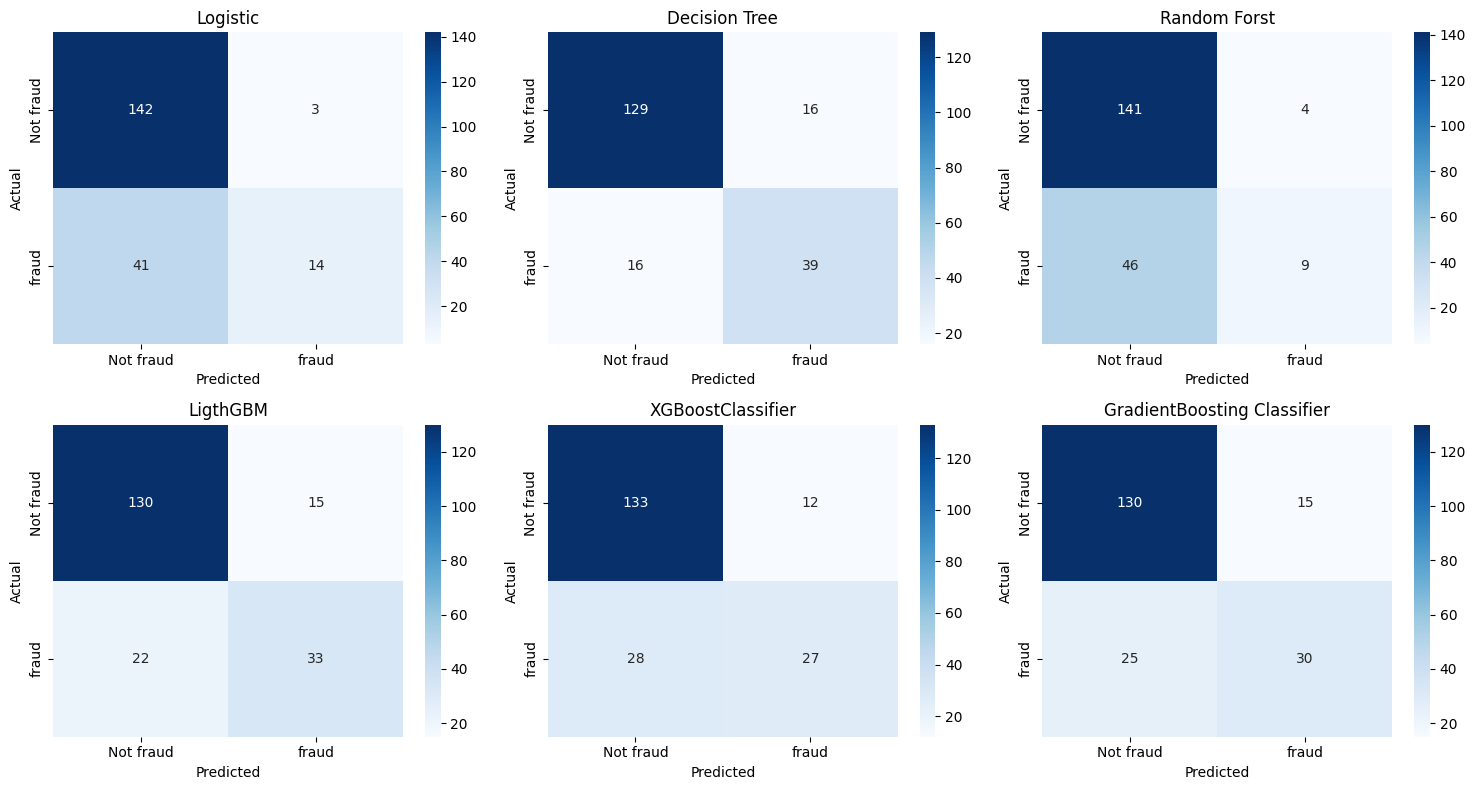

In [ ]:

confu_matrix_grid(models , x_train , x_test , y_train , y_test)

# **SMOTE Technique -- Handling Imbalanced Data**

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
target_col = ["fraud_reported"]
# Splitting the data
cols  = [i for i in df.columns if i not in target_col]
target_col = target_col

In [ ]:
# Split the Data
x_train_smote , x_test_smote , y_train_smote , y_test_smote = train_test_split(df[cols] , df[target_col] , test_size = 0.2 , random_state = 42)

print("Class Distribution Before Applying SMOTE Technique - ")
y_train.value_counts().reset_index()

Class Distribution Before Applying SMOTE Technique - 


,fraud_reported,count
0,0,608
1,1,192


In [ ]:
# Applying SMOTE Teachnique

smote = SMOTE(random_state = 42)
x_train_resampled , y_train_resampled = smote.fit_resample(x_train_smote , y_train_smote)

In [ ]:
print("Class Distribution After Applying SMOTE Technique - ")
y_train_resampled.value_counts().reset_index()

Class Distribution After Applying SMOTE Technique - 


,fraud_reported,count
0,0,608
1,1,608


**Logistic Regression**

In [ ]:

def model(model , x_train , x_test  , y_train , y_test , title):
  model.fit(x_train , y_train)
  predictions = model.predict(x_test)
  probabilities = model.predict_proba(x_test)

  print(classification_report(y_test , predictions))
  print("Accuracy Score - " , accuracy_score(y_test , predictions))
  print("Precision Score - " , precision_score(y_test , predictions))
  print("Recall Score - " , recall_score(y_test , predictions))

  confu_matrix = confusion_matrix(y_test , predictions)
  # print("Confusion matrix - " , confu_matrix)

  # sns.heatmap(confu_matrix  , annot=True , cmap=plt.cm.copper)
  # plt.title(f"Confusion matrix" , fontsize = 12)
  sns.heatmap(confu_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=["Not churn", "Churn"],
                    yticklabels=["Not churn", "Churn"])
  plt.xlabel("Predicted")
  plt.ylabel("Actual")

  model_roc_auc = roc_auc_score(y_test , predictions)
  print("Roc Auc Score - " , model_roc_auc)

  fpr , tpr , threshold = roc_curve(y_test , predictions)
  dt_roc_curve(fpr , tpr , title)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_smote = LogisticRegression(
    C = 100 ,

)
log_smote.fit(x_train_resampled , y_train_resampled)
predictions = log_smote.predict(x_test)
probabilities = log_smote.predict_proba(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



In [ ]:
print( "Classification report - " , classification_report(y_test , predictions))
print("Accuracy Score - " , accuracy_score(y_test , predictions))
print("Precision Score - " , precision_score(y_test , predictions))
print("Recall Score - " , recall_score(y_test , predictions))

Classification report -                precision    recall  f1-score   support

           0       0.77      0.70      0.73       145
           1       0.35      0.44      0.39        55

    accuracy                           0.62       200
   macro avg       0.56      0.57      0.56       200
weighted avg       0.65      0.62      0.64       200

Accuracy Score -  0.625
Precision Score -  0.35294117647058826
Recall Score -  0.43636363636363634


In [ ]:

# confusion matrix
conf_matrix = confusion_matrix(y_test , predictions)
print(conf_matrix)

# roc_auc_score
model_roc_auc = roc_auc_score(y_test  , predictions)
print("Area under curve - " , model_roc_auc)

[[101  44]
 [ 31  24]]
Area under curve -  0.5664576802507838


Text(0.5, 1.0, 'Confusion matrix - Logistic Rgression')

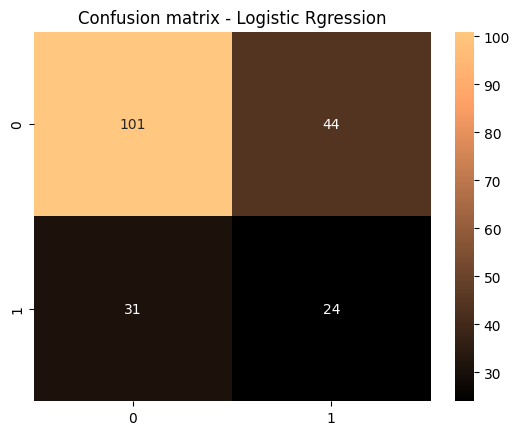

In [ ]:

y_pred = log_smote.predict(x_test)

log_reg_cf = confusion_matrix(y_test , y_pred)

# Logistic refression confusion matrix
sns.heatmap(log_reg_cf  , annot=True , cmap=plt.cm.copper , fmt = "-d")
plt.title("Confusion matrix - Logistic Rgression" , fontsize = 12)

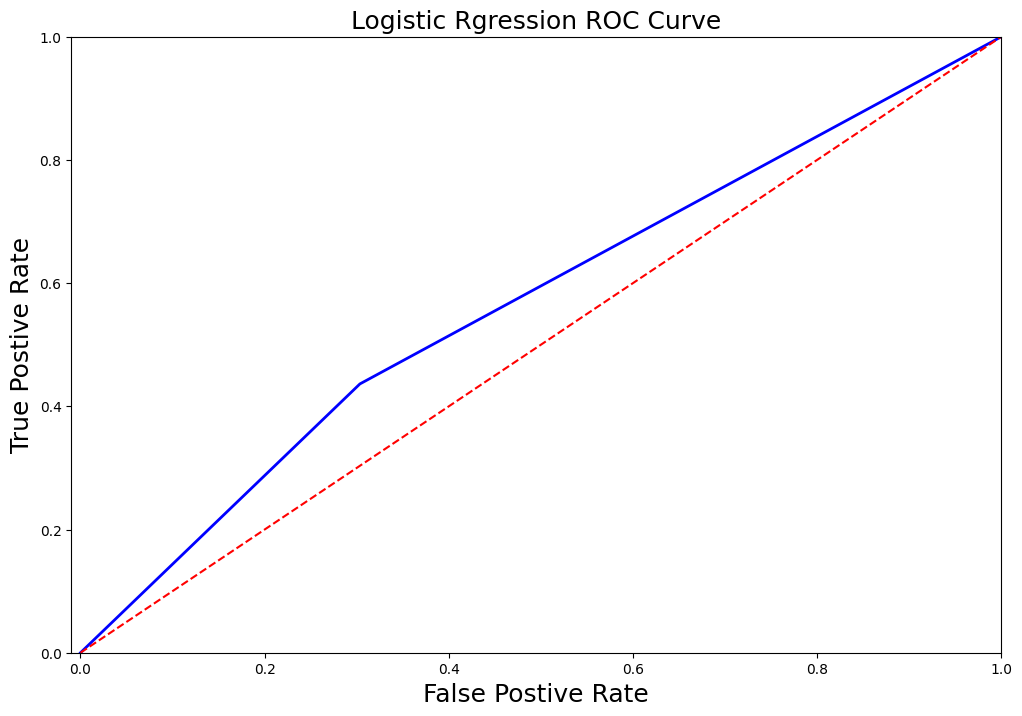

In [ ]:
fpr , tpr , threshold = roc_curve(y_test , predictions)

def logistic_roc_curve(log_fpr , log_tpr):
  plt.figure(figsize = (12 , 8))
  plt.title("Logistic Rgression ROC Curve" , fontsize = 18)
  plt.plot(log_fpr , log_tpr , "b-" , linewidth = 2)
  plt.plot([0,1] , [0,1] , "r--")
  plt.xlabel("False Postive Rate" , fontsize = 18)
  plt.ylabel("True Postive Rate" , fontsize = 18)
  plt.axis([-0.01 , 1 , 0 , 1])
  plt.show()

logistic_roc_curve(fpr , tpr)

**DecisionTree**

In [ ]:
from sklearn.tree import  DecisionTreeClassifier
dt_smote = DecisionTreeClassifier(
    max_depth = 8 ,
    splitter = "best"  ,
    criterion="gini" ,
)
dt_smote.fit(x_train_resampled  , y_train_resampled)

DecisionTreeClassifier(max_depth=8)

In [ ]:
predictions = dt_smote.predict(x_test)
probability = dt_smote.predict_proba(x_test)
print(classification_report(y_test , predictions))
print("accuracy score - " , accuracy_score(y_test , predictions))
print("Precision - " , precision_score(y_test , predictions))
print("Recall - " , recall_score(y_test , predictions))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       145
           1       0.65      0.64      0.64        55

    accuracy                           0.81       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.80      0.81      0.80       200

accuracy score -  0.805
Precision -  0.6481481481481481
Recall -  0.6363636363636364


In [ ]:
conf_matrix = confusion_matrix(y_test , predictions)
print("Confusion matrix - " , conf_matrix)

dt_model_auc = roc_auc_score(y_test , predictions)
print("Roc AUC Curve - " , dt_model_auc)

Confusion matrix -  [[126  19]
 [ 20  35]]
Roc AUC Curve -  0.7526645768025078


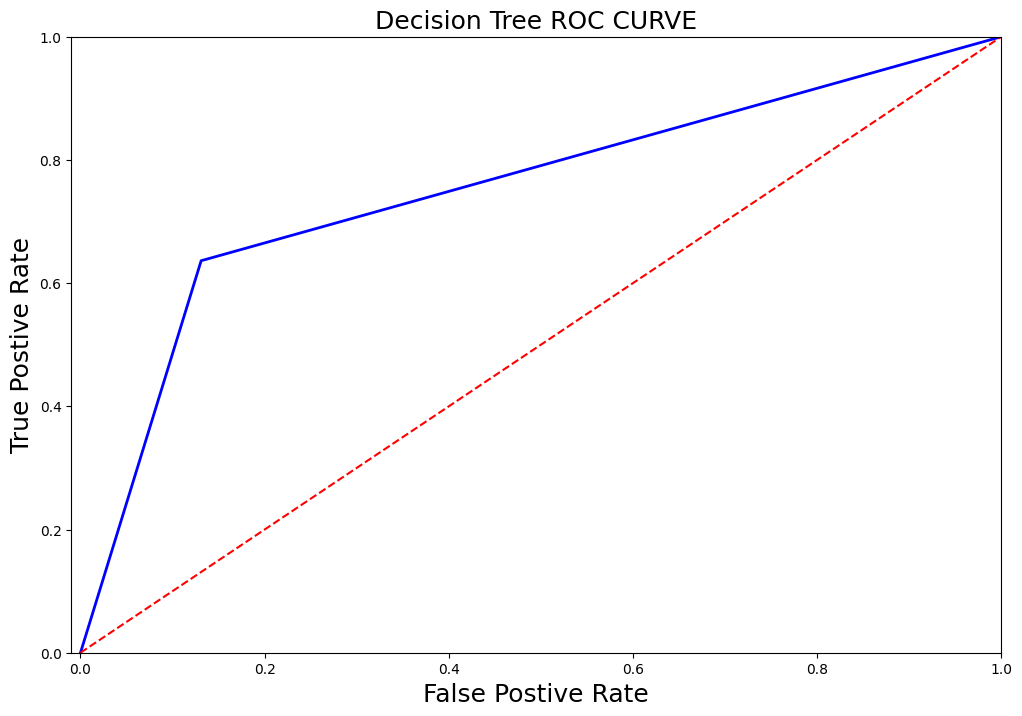

In [ ]:

fpr , tpr , threshold = roc_curve(y_test , predictions)

def dt_roc_curve(log_fpr , log_tpr , title):
  plt.figure(figsize = (12 , 8))
  plt.title(title , fontsize = 18)
  plt.plot(log_fpr , log_tpr , "b-" , linewidth = 2)
  plt.plot([0,1] , [0,1] , "r--")
  plt.xlabel("False Postive Rate" , fontsize = 18)
  plt.ylabel("True Postive Rate" , fontsize = 18)
  plt.axis([-0.01 , 1 , 0 , 1])
  plt.show()

dt_roc_curve(fpr , tpr , "Decision Tree ROC CURVE")

**RandomForest**

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



              precision    recall  f1-score   support

           0       0.86      0.88      0.87       145
           1       0.65      0.62      0.64        55

    accuracy                           0.81       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.80      0.81      0.80       200

Accuracy Score -  0.805
Precision Score -  0.6538461538461539
Recall Score -  0.6181818181818182
Roc Auc Score -  0.7470219435736677


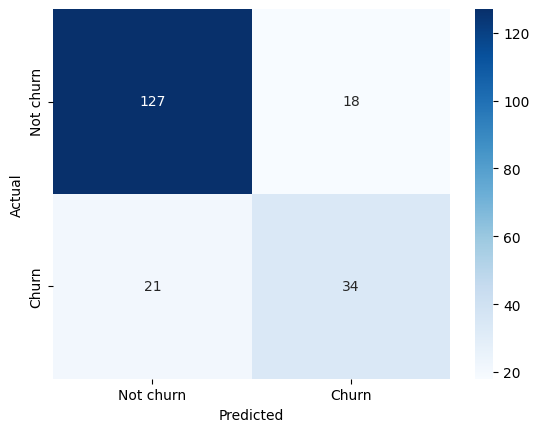

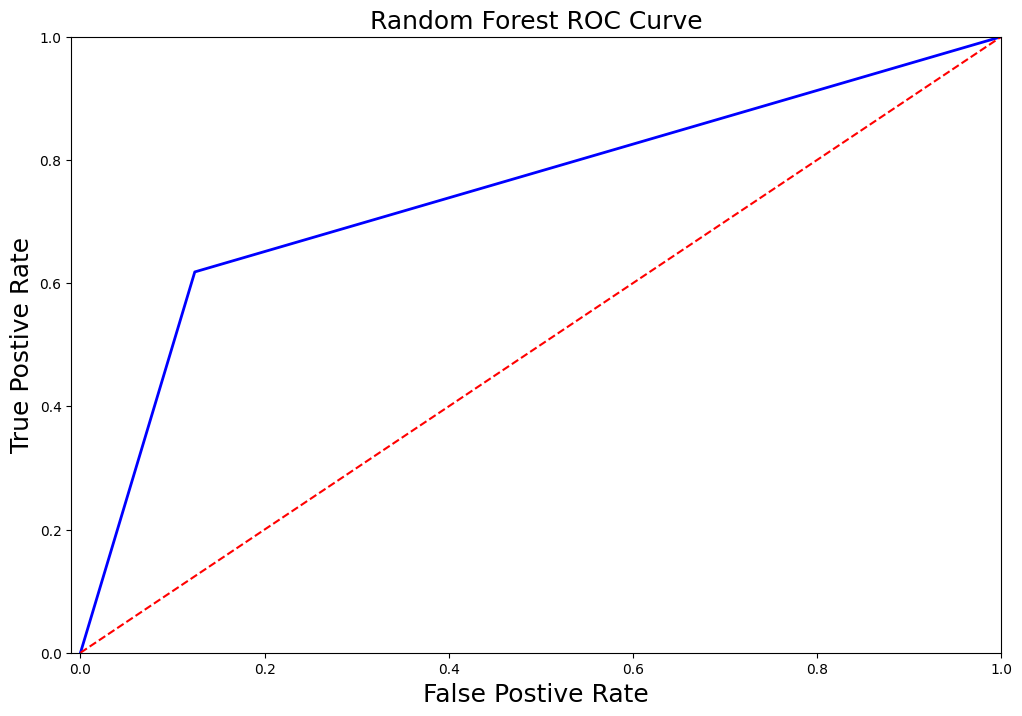

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc_smote = RandomForestClassifier(
    n_estimators= 600 ,
    max_depth = 9 ,
    criterion="gini"
)
model(rfc_smote , x_train_resampled , x_test  , y_train_resampled  , y_test , "Random Forest ROC Curve")

**lightgbm**

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 608, number of negative: 608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3358
[LightGBM] [Info] Number of data points in the train set: 1216, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

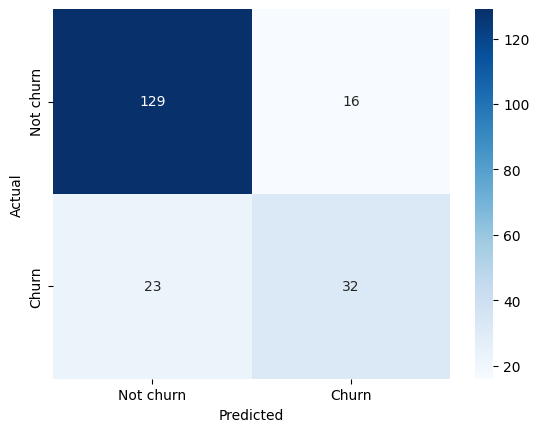

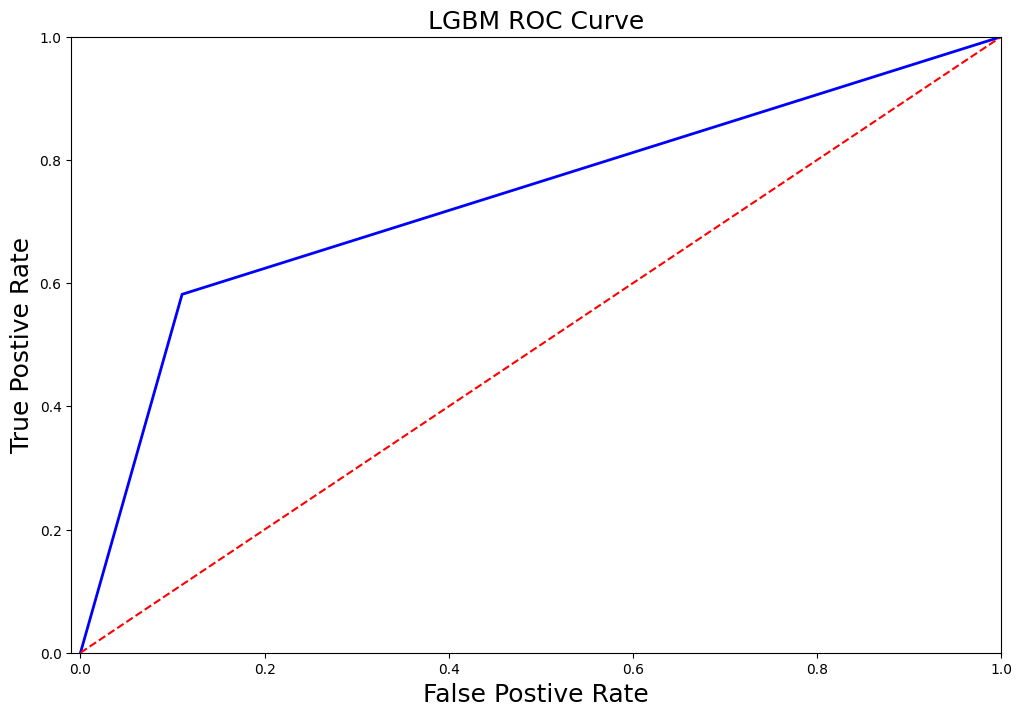

In [ ]:
from lightgbm import LGBMClassifier

lgbmc_smote = LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                        learning_rate=0.5, max_depth=7, min_child_samples=20,
                        min_child_weight=0.001, min_split_gain=0.0, n_estimators=100,
                        n_jobs=-1, num_leaves=500, objective='binary', random_state=None,
                        reg_alpha=0.0, reg_lambda=0.0, silent=True, subsample=1.0,
                        subsample_for_bin=200000, subsample_freq=0)

model(lgbmc_smote , x_train_resampled,x_test , y_train_resampled , y_test , "LGBM ROC Curve")

**XGBoost**

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       145
           1       0.71      0.71      0.71        55

    accuracy                           0.84       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.84      0.84      0.84       200

Accuracy Score -  0.84
Precision Score -  0.7090909090909091
Recall Score -  0.7090909090909091
Roc Auc Score -  0.799373040752351


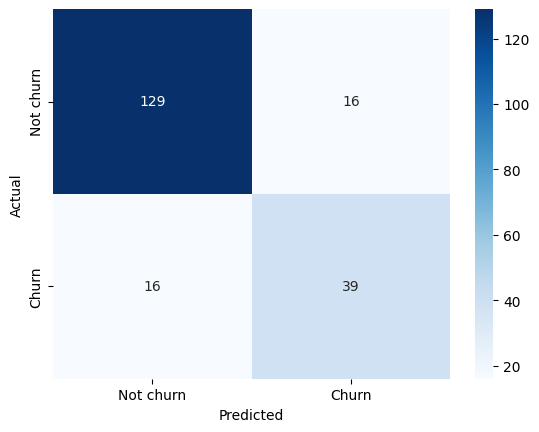

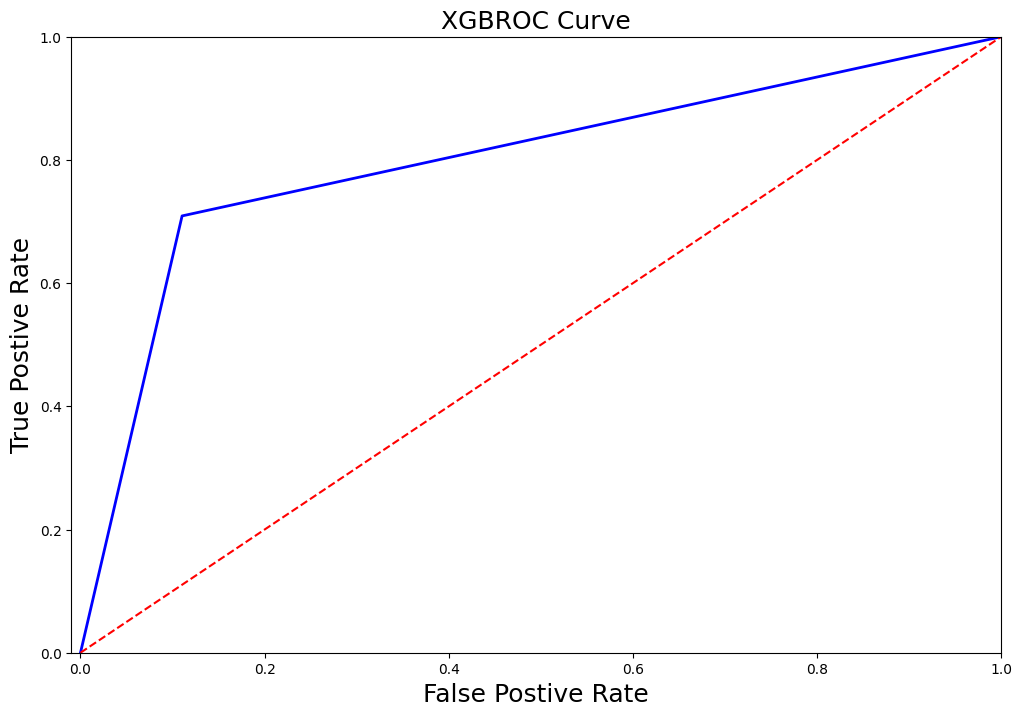

In [ ]:

from math import gamma
from xgboost import XGBClassifier

xgc_smote = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
                    colsample_bytree=1, gamma=0, learning_rate=0.9, max_delta_step=0,
                    max_depth=7, min_child_weight=1, n_estimators=100,
                    n_jobs=1, objective='binary:logistic', random_state=0,
                    reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
                     subsample=1)
model(xgc_smote , x_train_resampled , x_test , y_train_resampled , y_test , "XGBROC Curve")

**GradientBoosting**

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



              precision    recall  f1-score   support

           0       0.93      0.86      0.89       145
           1       0.69      0.82      0.75        55

    accuracy                           0.85       200
   macro avg       0.81      0.84      0.82       200
weighted avg       0.86      0.85      0.85       200

Accuracy Score -  0.85
Precision Score -  0.6923076923076923
Recall Score -  0.8181818181818182
Roc Auc Score -  0.8401253918495297


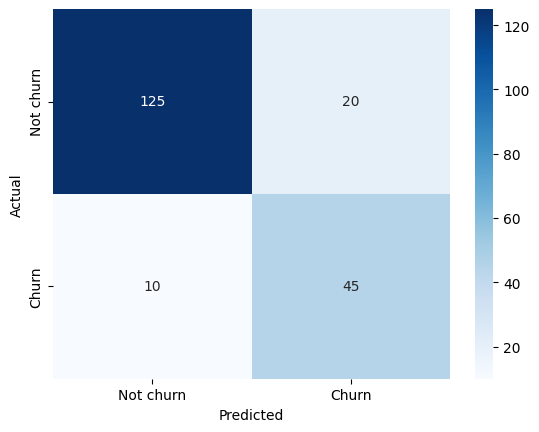

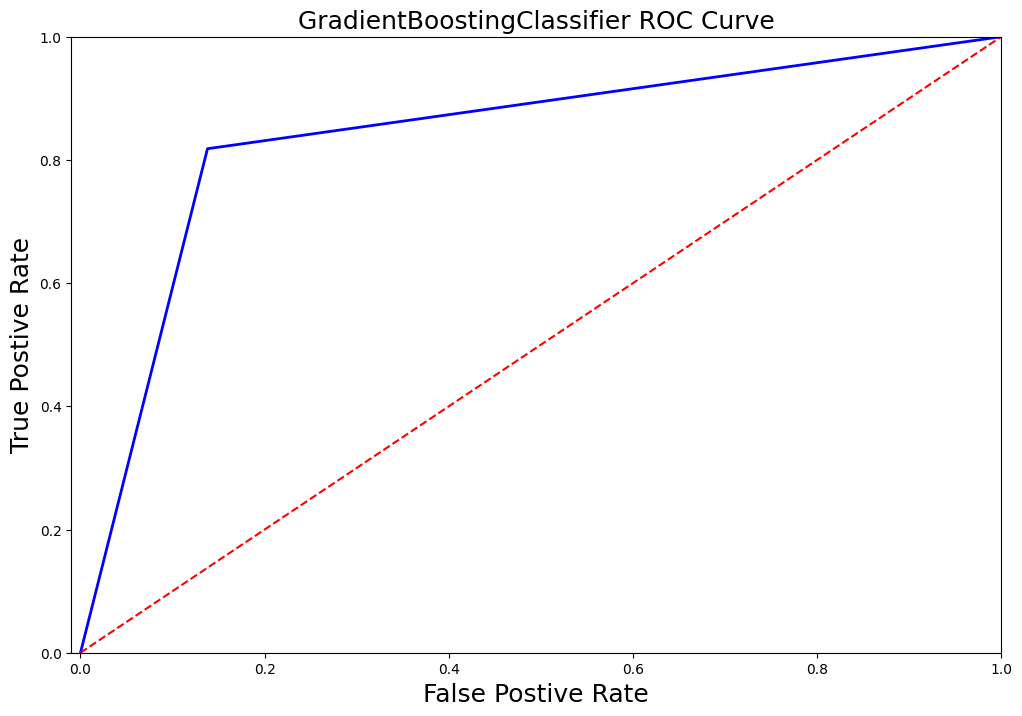

In [ ]:

from sklearn.ensemble import GradientBoostingClassifier
gbc_smote = GradientBoostingClassifier(
    n_estimators=100 ,
    random_state=124
)
model(gbc_smote , x_train_resampled ,x_test , y_train_resampled , y_test , "GradientBoostingClassifier ROC Curve")

**Model Perfromance After Applying Imbalanced  Teachnique**

In [ ]:
models_smote = {
    "Logistic": log_smote ,
    "Decision Tree" : dt_smote ,
    "Random Forst" : rfc_smote ,
    "LigthGBM" : lgbmc_smote ,
    "XGBoostClassifier" :xgc_smote ,
    "GradientBoosting Classifier" : gbc_smote

}

In [ ]:

# model Perfomance
def model_report(model , x_train ,x_test , y_train , y_test , name):
  model = model.fit(x_train , y_train)
  predictions = model.predict(x_test)
  accuracy = accuracy_score(y_test, predictions)
  recallscore = recall_score(y_test, predictions)
  precision = precision_score(y_test, predictions)
  roc_auc = roc_auc_score(y_test, predictions)
  f1score = f1_score(y_test, predictions)


  df = pd.DataFrame({
      "Model"  : [name],
      "Accuracy" : [accuracy],
      "Recall"   : [recallscore],
      "Precision": [precision],
      "f1-score" : [f1score],
      "Roc_auc"  : [roc_auc],
  })

  return df

In [ ]:
final_results = pd.DataFrame()

for name, model in models_smote.items():
    report_df = model_report(model, x_train, x_test, y_train, y_test, name)
    final_results = pd.concat([final_results, report_df], ignore_index=True)

final_results

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: Dat

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 192, number of negative: 608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2299
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240000 -> initscore=-1.152680
[LightGBM] [Info] Start training from score -1.152680
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

,Model,Accuracy,Recall,Precision,f1-score,Roc_auc
0,Logistic,0.775,0.272727,0.750000,0.400000,0.619122
1,Decision Tree,0.785,0.581818,0.615385,0.598131,0.721944
2,Random Forst,0.760,0.200000,0.733333,0.314286,0.586207
3,LigthGBM,0.815,0.600000,0.687500,0.640777,0.748276
4,XGBoostClassifier,0.785,0.527273,0.630435,0.574257,0.705016
5,GradientBoosting Classifier,0.800,0.545455,0.666667,0.600000,0.721003


1.LightGBM (0.815 Accuracy)
LightGBM is clearly our best performer. It didn't just guess; it learned the patterns effectively.

  - F1-Score (0.64): The highest in our list, meaning it has the best balance.

  - Recall (0.60): It caught 60% of all fraud cases. While not 100%, it is significantly better than the basic models.

  - Precision (0.68): When it says "Fraud," it is correct 68% of the time. This means fewer innocent customers are harassed.



2.Gradient Boosting (0.800 Accuracy)


- Recall (0.54): It catches about half of the frauds.

- Precision (0.66): It is fairly reliable but slightly less accurate than LightGBM.

- The Aggressive Model: Decision Tree (0.780 Accuracy)


- Recall (0.56): It has a decent catch rate, but its Precision (0.60) is lower. This means it might flag more honest customers as suspicious compared to LightGBM.

3. The Worst  Models: Logistic Regression & Random Forest
Even after SMOTE, these models struggled:

    - Random Forest Recall (0.20): This is very poor for fraud detection. It missed 80% of the fraudsters!

# **Hyperparameter Turning**

In [ ]:

lgbmc = LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                        learning_rate=0.5, max_depth=7, min_child_samples=20,
                        min_child_weight=0.001, min_split_gain=0.0, n_estimators=100,
                        n_jobs=-1, num_leaves=500, objective='binary', random_state=None,
                        reg_alpha=0.0, reg_lambda=0.0, silent=True, subsample=1.0,
                        subsample_for_bin=200000, subsample_freq=0)

In [ ]:
from sklearn.model_selection import  GridSearchCV

lgbmc_smote_params = {
    "max_depth": [7,10,15,20,20] ,
    "n_estimators":[200 , 300 , 400 , 500]
}

grid_lgbmc = GridSearchCV(LGBMClassifier() , lgbmc_smote_params)
grid_lgbmc.fit(x_train_resampled , y_train_resampled)
lgbmc = grid_lgbmc.best_estimator_
lgbmc

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Info] Number of positive: 486, number of negative: 486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3319
[LightGBM] [Info] Number of data points in the train set: 972, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



...

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBMClassifier(max_depth=10, n_estimators=200)

In [ ]:
print(f"LGBMC - {lgbmc}")

LGBMC - LGBMClassifier(max_depth=10, n_estimators=200)


In [ ]:
from sklearn.model_selection import cross_val_score , cross_val_predict

lgbmc_score = cross_val_score(lgbmc , x_train_resampled , y_train_resampled , cv = 5)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Info] Number of positive: 486, number of negative: 486
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3319
[LightGBM] [Info] Number of data points in the train set: 972, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Info] Number of positive: 486, number of negative: 487
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000753 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3085
[LightGBM] [Info] Number of data points in the train set: 973, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499486 -> initscore=-0.002055
[LightGBM] [Info] Start training from score -0.002055
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [ ]:
print("--------------------------------------------------------------------------")
print("--------------------------------------------------------------------------")
print("--------------------------------------------------------------------------")
print(f"lgbmc Cross Validation Score - " , round(lgbmc_score.mean()*100 , 2).astype(str) + "%")
print("--------------------------------------------------------------------------")
print("--------------------------------------------------------------------------")
print("--------------------------------------------------------------------------")


--------------------------------------------------------------------------
--------------------------------------------------------------------------
--------------------------------------------------------------------------
lgbmc Cross Validation Score -  89.65%
--------------------------------------------------------------------------
--------------------------------------------------------------------------
--------------------------------------------------------------------------


In [ ]:
lgbmc_predict = cross_val_predict(lgbmc , x_train_resampled , y_train_resampled , cv = 5)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Info] Number of positive: 486, number of negative: 486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000513 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3319
[LightGBM] [Info] Number of data points in the train set: 972, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 487, number of negative: 486
[LightGBM] [Info] Auto-choosing c

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [ ]:
print("lgbmc  Roc Auc Score:" , roc_auc_score(y_train_resampled , lgbmc_predict))

lgbmc  Roc Auc Score: 0.8963815789473685


In [ ]:
lgbmc_scores = lgbmc.predict_proba(x_test)[: , -1]

In [ ]:
lgbmc_fpr , lgbmc_tpr , lgbmc_threshold = roc_curve(y_test , lgbmc_scores)
lgbmc_auc = roc_auc_score(y_test, lgbmc_scores)

In [ ]:
trace0 = go.Scatter(
    x=gbc_fpr,
    y=gbc_tpr,
    mode='lines',
    name=f'LGBMC  (Area = {lgbmc_auc:.2f})'
)
layout = go.Layout(
    title = "Receiver Operating Characteristic",
    xaxis = dict(title = "False Psoitive Rate") ,
    yaxis = dict(title = "True Positive Rate"),
    autosize = False ,
    width = 800 ,
    height = 800 ,
    showlegend = True
)

fig = go.Figure(data = trace0 , layout = layout)

fig.show()

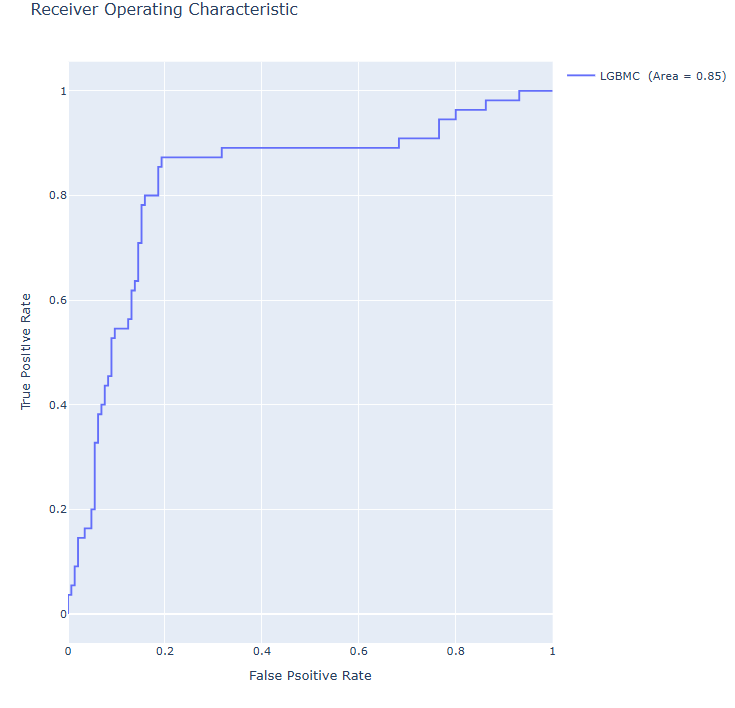

In [ ]:


lgbmc_hyper = LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                        learning_rate=0.5, max_depth=10, min_child_samples=20,
                        min_child_weight=0.001, min_split_gain=0.0, n_estimators=200,
                        n_jobs=-1, num_leaves=500, objective='binary', random_state=None,
                        reg_alpha=0.0, reg_lambda=0.0, silent=True, subsample=1.0,
                        subsample_for_bin=200000, subsample_freq=0)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 608, number of negative: 608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000603 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3358
[LightGBM] [Info] Number of data points in the train set: 1216, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

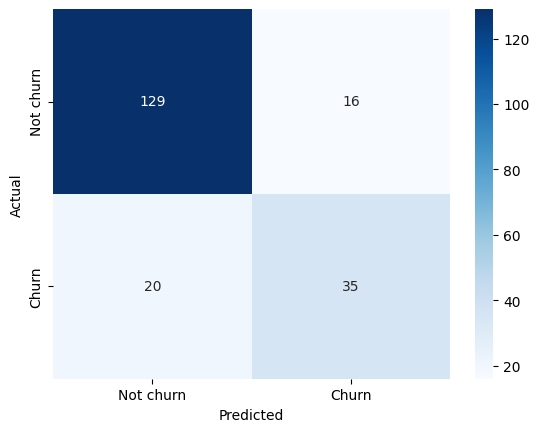

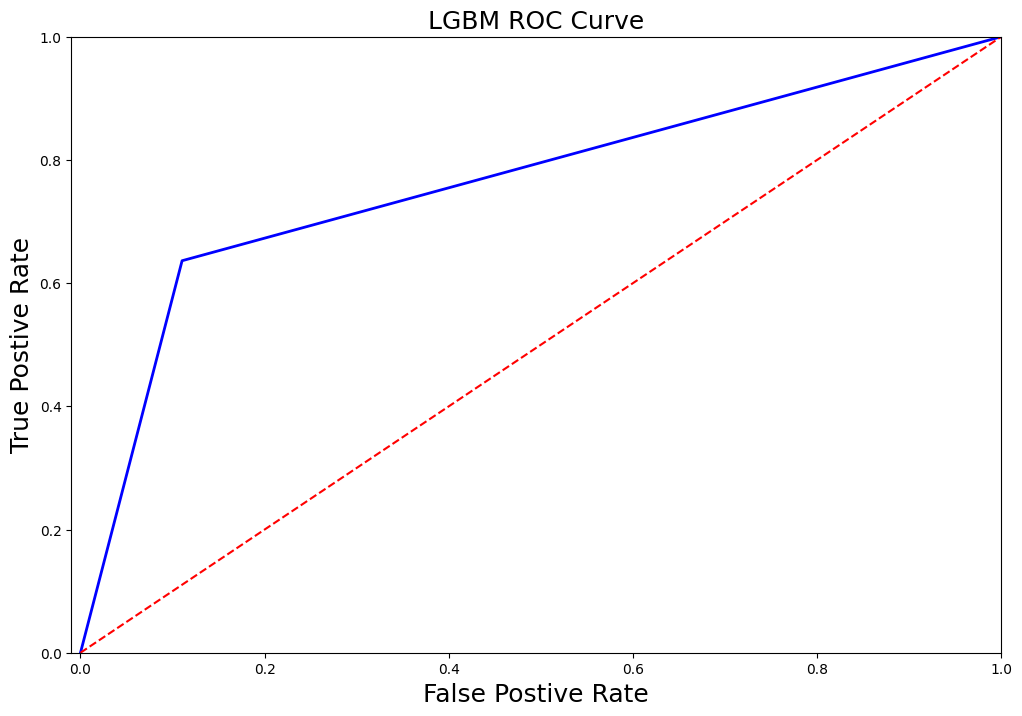

In [ ]:
model(lgbmc_hyper , x_train_resampled,x_test , y_train_resampled , y_test , "LGBM ROC Curve")

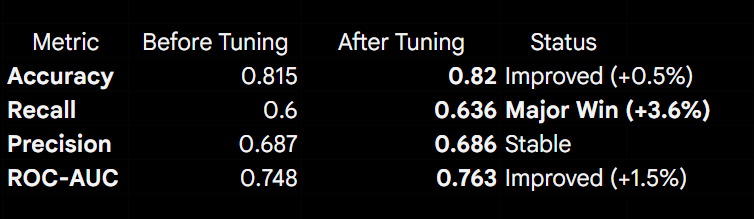

In [ ]:
import pickle
filename = "lgbmc_hyper.pkl"
pickle.dump(lgbmc_hyper , open(filename , "wb"))


In [ ]:
# loading back pickle file

lgbmc_load = pickle.load(open(filename, 'rb'))

In [ ]:
lgbmc_load

LGBMClassifier(learning_rate=0.5, max_depth=10, n_estimators=200, n_jobs=-1,
               num_leaves=500, objective='binary', silent=True)